# SDSS fit: J102839.11+450009.4 with tight Fe FWHM priors

This notebook fetches the SDSS spectrum for `J102839.11+450009.4`, sets Fe UV/optical FWHM priors with NumPyro distributions, and disables the host through `cfg.host.enabled = False`.

Set `config.inference.method = "optax"` for staged SVI/Optax MAP optimization (continuum warm start, then full model). Set `config.inference.method = "optax+nuts"` to use that staged MAP point to initialize NUTS.



In [1]:
import numpy as np
import numpyro.distributions as dist
from astroquery.sdss import SDSS
from astropy.coordinates import SkyCoord
from astropy import units as u

import jaxqsofit
from jaxqsofit import (
    ContinuumConfig,
    HostConfig,
    InferenceConfig,
    JAXQSOFit,
    LineConfig,
    Observation,
    OutputConfig,
    FitConfig,
    PriorConfig,
    SpectroscopyData,
)



/Users/colinburke/miniforge3/envs/jaxcpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
coord = SkyCoord.from_name("J102839.11+450009.4")
xid = SDSS.query_region(coord, spectro=True, radius=5 * u.arcsec)
sp = SDSS.get_spectra(matches=xid[:1])[0]

tb = sp[1].data
lam = np.asarray(10 ** tb["loglam"], dtype=float)
flux = np.asarray(tb["flux"], dtype=float)
ivar = np.asarray(tb["ivar"], dtype=float)

err = np.full_like(flux, 1e-6)
m = np.isfinite(ivar) & (ivar > 0)
err[m] = 1.0 / np.sqrt(ivar[m])

z = float(sp[2].data["z"][0])
ra = float(coord.ra.deg)
dec = float(coord.dec.deg)
plateid = int(sp[0].header.get("plateid", 0))
mjd = int(sp[0].header.get("mjd", 0))
fiberid = int(sp[0].header.get("fiberid", 0))
sdss_filename = f"{plateid:04d}-{mjd}-{fiberid:04d}"

lam.size, z, sdss_filename



(3831, 0.5834615230560303, '1429-52990-0401')

In [3]:
prior_config = PriorConfig.from_spectrum(flux=flux, redshift=z)

fscale = np.nanmedian(np.abs(flux[np.isfinite(flux)]))

prior_config.fe.uv_norm = dist.LogNormal(
    loc=np.log(max(0.03 * fscale, 1e-12)),
    scale=1.0,
)
prior_config.fe.op_over_uv = dist.Normal(loc=0.0, scale=1.0)
prior_config.feii.uv_fwhm = dist.LogNormal(loc=np.log(3000.0), scale=0.5)
prior_config.feii.optical_fwhm = dist.LogNormal(loc=np.log(3000.0), scale=0.5)
prior_config.feii.fractional_error = dist.TruncatedNormal(
    loc=0.20,
    scale=0.05,
    low=0.0,
    high=0.50,
)



/Users/colinburke/research/jaxqsofit/src/jaxqsofit/core.py:3952: RuntimeWarning: Mean of empty slice.
  tmp_SN = np.array([flux[ind5100].mean() / flux[ind5100].std(), flux[ind3000].mean() / flux[ind3000].std(), flux[ind1350].mean() / flux[ind1350].std()])
/Users/colinburke/miniforge3/envs/jaxcpu/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/colinburke/miniforge3/envs/jaxcpu/lib/python3.12/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/colinburke/miniforge3/envs/jaxcpu/lib/python3.12/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/colinburke/miniforge3/envs/jaxcpu/lib/python3.12/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encoun

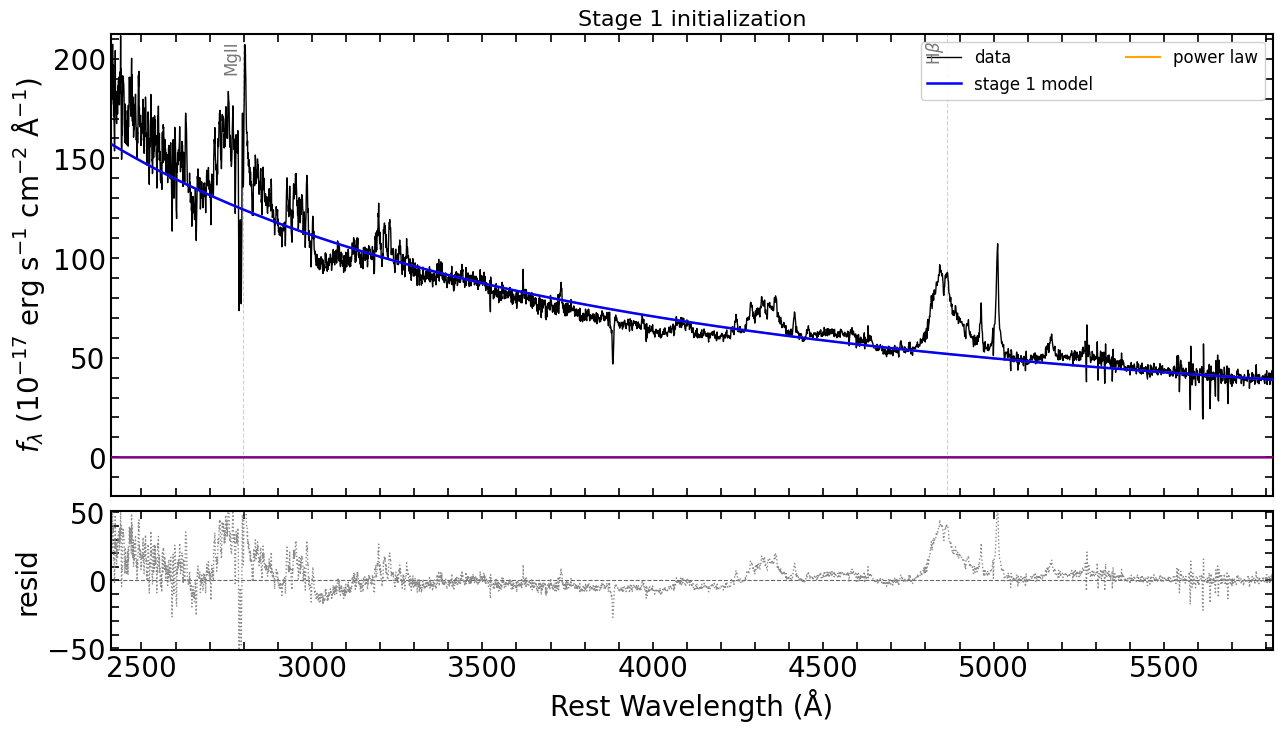

100%|██████████| 400/400 [00:06<00:00, 59.49it/s, init loss: 6680.7934, avg. loss [381-400]: 5505.5822] 


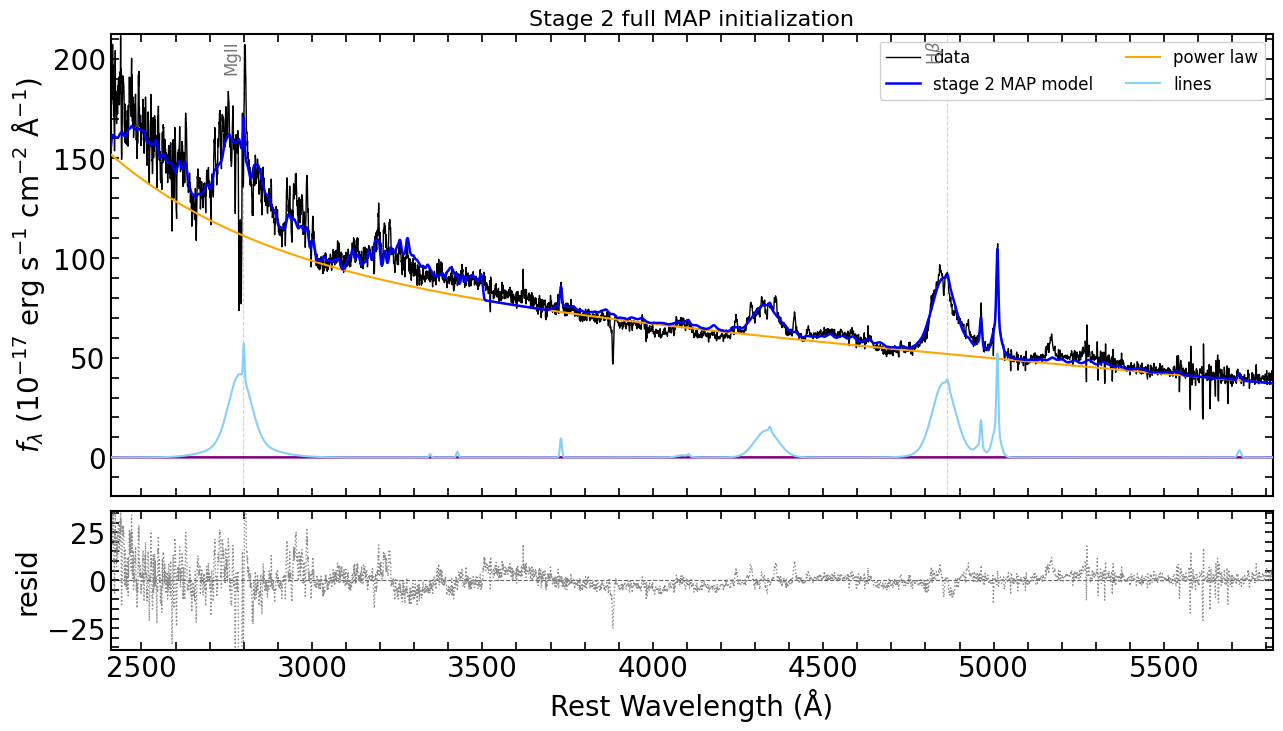

max data        : 211.55670693958675
max total model : 170.53930805247919
max PL          : 152.12890759348076
max host        : 0.0
max FeII UV     : 24.95635062412798
max FeII opt    : 4.456895747679441
max Balmer cont : 0.0
max lines       : 57.15913569574816


sample: 100%|██████████| 300/300 [03:13<00:00,  1.55it/s, 255 steps of size 2.10e-02. acc. prob=0.84]



                                           mean       std    median      5.0%     95.0%     n_eff     r_hat
                          Fe_FWHM_std     -1.99      0.15     -1.99     -2.21     -1.77    102.82      1.02
                         Fe_shift_std      0.70      0.15      0.70      0.40      0.90     85.86      1.03
                       Fe_uv_norm_std      2.86      0.04      2.86      2.80      2.95    137.75      1.00
             PL_apparent_log_norm_std      1.03      0.00      1.03      1.02      1.04     98.92      0.99
                PL_apparent_slope_std      0.09      0.03      0.09      0.04      0.14     76.05      1.02
                   frac_fe_jitter_std      0.14      0.58      0.21     -0.82      0.97    126.24      1.00
                      frac_jitter_std      0.98      0.12      0.97      0.78      1.16    134.42      0.99
          line_OIII_wing_log_fwhm_std     -0.05      0.49     -0.22     -0.46      0.67     18.59      1.02
                line_amp_Fe

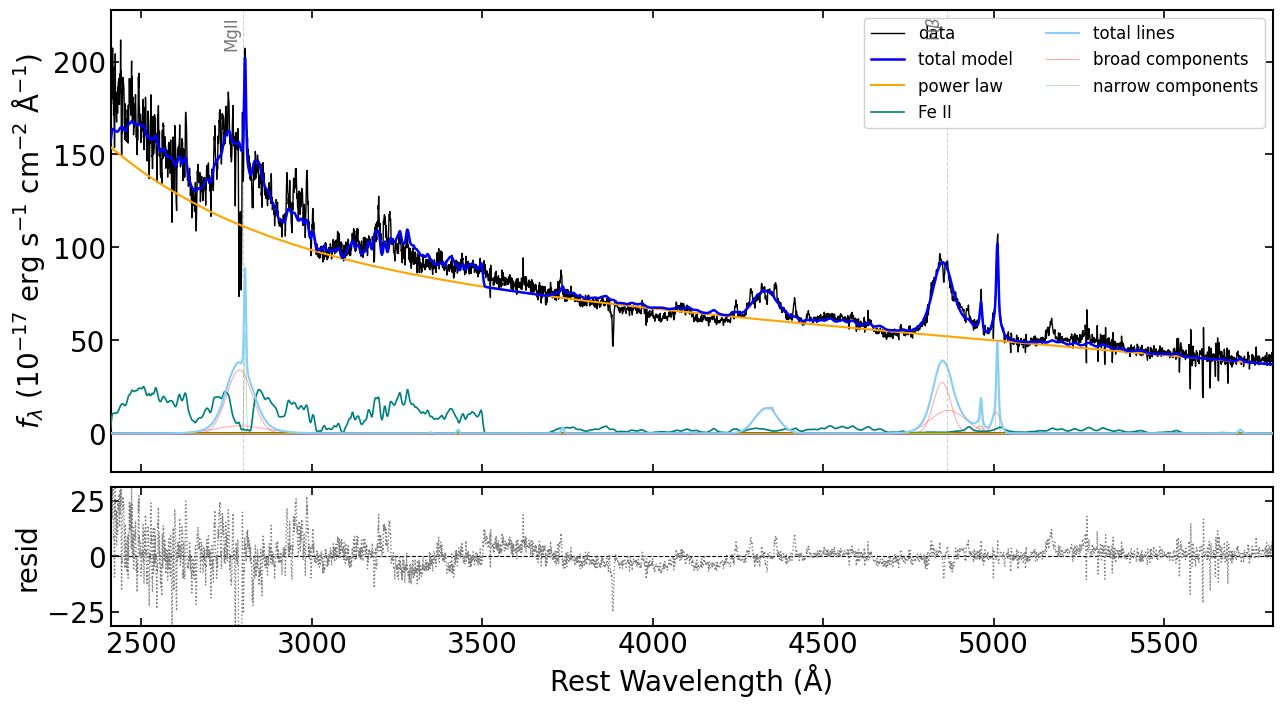

In [4]:
cfg = FitConfig(
    observation=Observation(
        object_id=sdss_filename,
        redshift=z,
        ra=ra,
        dec=dec,
        apply_mw_deredden=True,
    ),
    spectroscopy=SpectroscopyData(
        wave_obs=lam,
        fluxes=flux,
        errors=err,
        resolving_power=2000
    ),
    continuum=ContinuumConfig(
        fit_power_law=True,
        fit_feii=True,
        fit_balmer_continuum=False,
        fit_polynomial_tilt=True,
        fit_reddening=True,
    ),
    host=HostConfig(enabled=False, dsps_ssp_fn='../tempdata.h5'),
    lines=LineConfig(enabled=True, include_high_ionization_lines=True),
    inference=InferenceConfig(
        method='optax+nuts',
        map_steps=600,
        learning_rate=1e-2,
        num_warmup=200,
        num_samples=100,
        num_chains=1,
        dense_mass=False,
        line_block_dense_mass=True,
        standardize_active_priors=True,
        plot_init=True,
        max_tree_depth=8,
        target_accept_prob=0.85,
    ),
    output=OutputConfig(output_path='.', save_result=False, plot_fig=True, save_fig=False, show_plot=True),
    prior_config=prior_config,
)

q = JAXQSOFit(cfg)
result = q.fit()



In [5]:
q.plot_mcmc_diagnostics(
    param_names='Fe_uv_FWHM',
    do_trace=True,
    do_corner=True,
    max_vector_elems=2,
    corner_bins=25,
    corner_max_points=1500,
)

